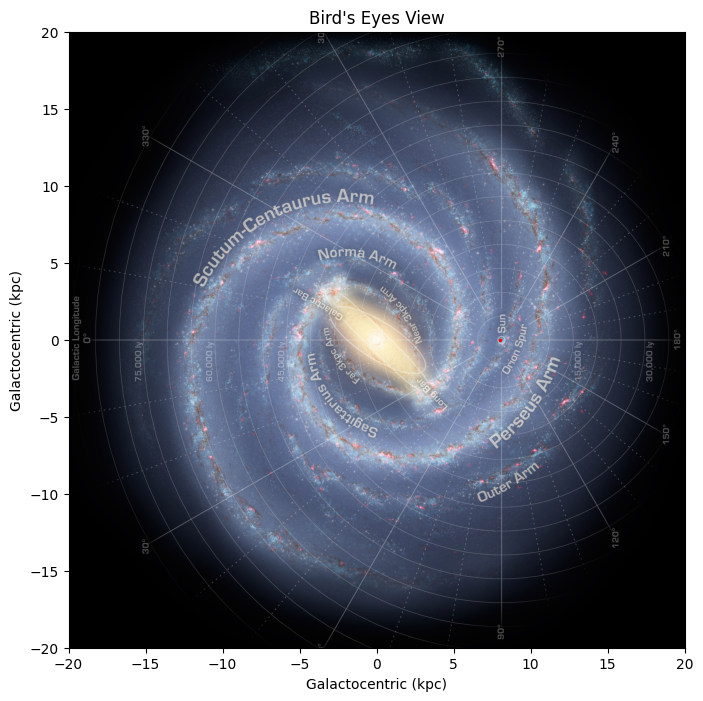

In [2]:
import numpy as np

from astropy import units as u

from mw_plot import MWFaceOn

mw1 = MWFaceOn(

    radius=20 * u.kpc,

    unit=u.kpc,

    coord="galactocentric",

    annotation=True,

    figsize=(10, 8),

)

mw1.title = "Bird's Eyes View"

mw1.scatter(8 * u.kpc, 0 * u.kpc, c="r", s=2)

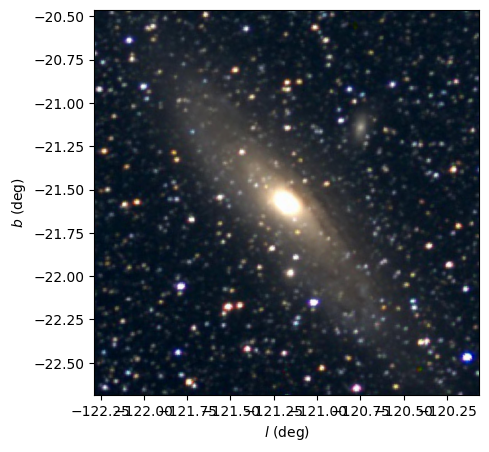

In [3]:
import matplotlib.pyplot as plt

from astropy import units as u

from mw_plot import MWSkyMap

mw1 = MWSkyMap(

    center="M31",

    radius=(4000, 4000) * u.arcsec,

    background="Mellinger color optical survey",

)

fig, ax = plt.subplots(figsize=(5, 5))

mw1.transform(ax)

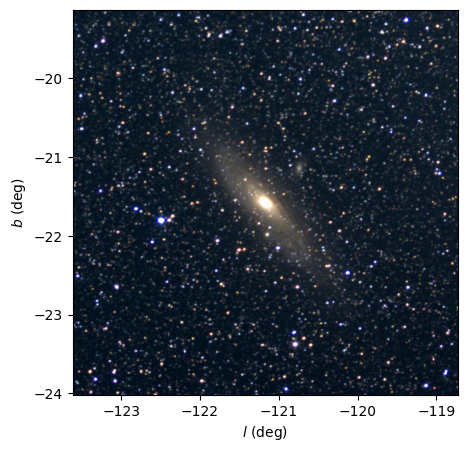

In [103]:
import matplotlib.pyplot as plt

from astropy import units as u

from mw_plot import MWSkyMap

mw1 = MWSkyMap(
    center="M31",
    radius=(8800, 8800) * u.arcsec,
    background="Mellinger color optical survey",
)

fig, ax = plt.subplots(figsize=(5, 5))

mw1.transform(ax)

In [104]:
buf = fig.canvas.tostring_argb()

In [139]:
ncols, nrows = fig.canvas.get_width_height()

lol = np.frombuffer(buf, dtype=np.uint8).reshape(ncols, nrows, 4)

ValueError: cannot reshape array of size 844336 into shape (500,500,4)

In [106]:
grey = lol * 0

grey = np.sum(lol[: , : , :] * np.array([0.299, 0.587, 0.114]), axis=2)

qwe = 0
dsa = 0
for i in lol:
    for j in i:
        if all(j == np.array([255, 255, 255])): 
            qwe += 1
        if all(j == np.array([0, 0, 0])): 
            dsa += 1
        
print(qwe, dsa)
print(grey.shape)

47794 553
(500, 500)


Y = 0.299 R + 0.587 G + 0.114 B

In [111]:
grey.shape

(500, 500)

In [112]:
Y = 0.299 *255, 0.587 *255,0.114 *255

In [121]:
x, y = [], []
for ig, g in enumerate(grey):
    for ij, j in enumerate(g):
        if j > 240:
            x.append(ig)
            y.append(ij)
    

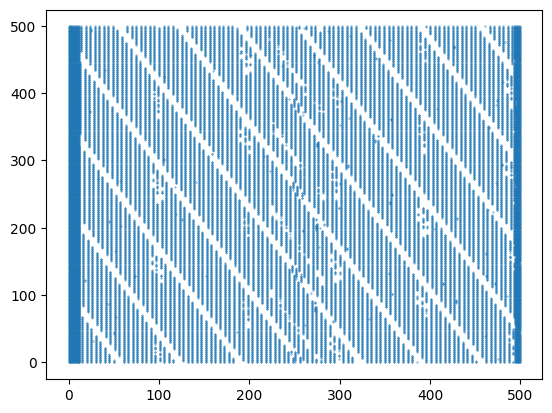

In [122]:
plt.scatter(x, y, s=0.1)

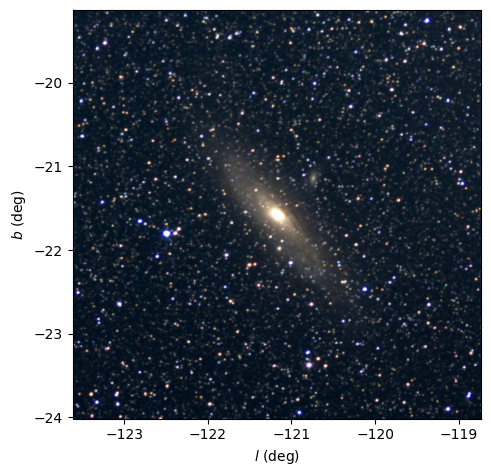

In [127]:
import matplotlib.pyplot as plt

from astropy import units as u

from mw_plot import MWSkyMap

mw1 = MWSkyMap(
    center="M31",
    radius=(8800, 8800) * u.arcsec,
    background="Mellinger color optical survey",
)

fig, ax = plt.subplots(figsize=(5, 5))

mw1.transform(ax)

mw1.savefig('galaxy.png')

In [140]:
 
def plt2rgbarr(fig, draw=True): 
    if draw:
        fig.canvas.draw()
    rgba_buf = fig.canvas.buffer_rgba()
    (w,h) = fig.canvas.get_width_height()
    rgba_arr = np.frombuffer(rgba_buf, dtype=np.uint8).reshape((h,w,4))
    return rgba_arr[:, :, :3]

In [141]:

img_array = plt2rgbarr(fig)
print(img_array.shape)  # (100, 100, 3)


(500, 500, 3)


array([255, 255, 255, 255], dtype=uint8)

In [142]:

grey = np.sum(img_array[: , : , :] * np.array([0.299, 0.587, 0.114]), axis=2)


In [145]:
x, y = [], []
for ig, g in enumerate(grey):
    for ij, j in enumerate(g):
        if j > 250:
            x.append(ig)
            y.append(ij)
    

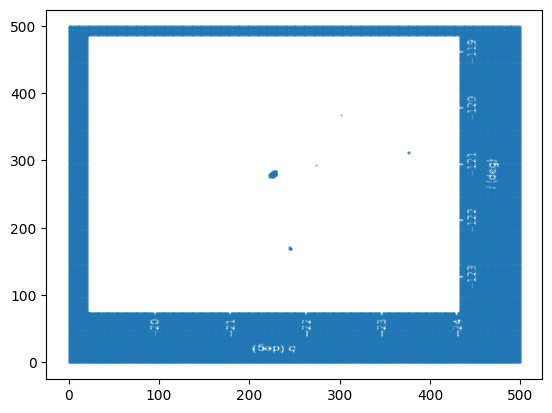

In [146]:
plt.scatter(x, y, s=0.1)